<a href="https://colab.research.google.com/github/Danny3431/2080-html-css-header-footer-variables/blob/main/Hora_de_practicar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sobre el notebook

Este cuaderno contiene diversos desafíos relacionados con los aprendizajes de cada clase. Es un cuaderno diseñado con el enunciado de cada desafío y un espacio para desarrollar y ejecutar sus soluciones. Si es necesario agregar más celdas de código para resolver el desafío, siéntase libre de hacerlo.

# Aula 1

### Desafío 1

Realice la lectura de la base de datos de diabetes y divida los datos en variables explicativas y variable objetivo (X e Y).

In [39]:
import pandas as pd

In [40]:
datos = pd.read_csv('/content/diabetes.csv')

In [41]:
datos

,glicemia,presion_sanguinea,grasa_subcutanea_triceps,insulina,imc,diabetes
0,66,23,94,28.1,0.167,0
1,40,35,168,43.1,2.288,1
2,50,32,88,31.0,0.248,1
3,70,45,543,30.5,0.158,1
4,60,23,846,30.1,0.398,1
...,...,...,...,...,...,...
389,88,44,510,43.3,0.222,1
390,88,39,110,36.5,1.057,1
391,58,26,16,28.4,0.766,0
392,76,48,180,32.9,0.171,0


La base de datos tiene solo 394 filas y 6 columnas. Podemos observar 6 columnas de datos: glicemia, presion_sanguinea, pliegue_cutaneo_triceps, insulina, imc y diabetes. La clasificación del modelo debe hacerse para la columna de diabetes, que presenta valores de 0 para ausencia de diabetes y 1 para presencia de diabetes, por lo tanto, esta es la variable objetivo y el resto son variables explicativas. Podemos realizar la división de los datos usando el código:

In [42]:
x = datos.drop('diabetes', axis = 1)
y = datos['diabetes']

### Desafío 2

Realice la división en datos de entrenamiento y datos para prueba.

Para realizar la división de datos entre entrenamiento, validación y prueba, podemos usar el método **train_test_split** de la biblioteca **Scikit-Learn**. Primero debemos importar la función con el código:

In [43]:
from sklearn.model_selection import train_test_split

La primera división se hará de los datos de prueba y luego con el resto se hará una nueva división entre entrenamiento y validación, usando el parámetro **stratify = y** para mantener la proporción de los datos de la variable objetivo entre los conjuntos.

Dado que la base de datos tiene pocos registros, solo se dividirá el **5%** de los datos para prueba para que haya una cantidad mayor de registros en la base de datos de entrenamiento:

In [44]:
x, x_test, y, y_test = train_test_split(x, y, stratify = y, test_size = 0.05, random_state = 5)
x_train, x_val, y_train, y_val = train_test_split(x, y, stratify = y, random_state = 5)

### Desafío 3

Cree 2 modelos utilizando los algoritmos [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) y [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) y evalúe la precisión en los datos de entrenamiento y prueba, eligiendo valores para el parámetro `max_depth` para evitar que los modelos se especialicen demasiado en el patrón de los datos de entrenamiento.

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Después de la importación de los algoritmos, podemos instanciar los modelos y almacenarlos en variables, aquí se eligieron los valores de max_depth = 3 para el DecisionTree y max_depth = 2 para el RandomForest:

In [46]:
arbol = DecisionTreeClassifier(max_depth = 3)
random_forest = RandomForestClassifier(max_depth = 2)

Para hacer el ajuste de los modelos podemos usar el método **fit()** y para evaluar la tasa de acierto, el método **score()**:

In [47]:
arbol.fit(x_train, y_train)
print(f'Exactitud de entrenamiento: {arbol.score(x_train, y_train)}')
print(f'Exactitud de validación: {arbol.score(x_val, y_val)}')

Exactitud de entrenamiento: 0.7571428571428571
Exactitud de validación: 0.776595744680851


In [48]:
random_forest.fit(x_train, y_train)
print(f'Exactitud de entrenamiento: {random_forest.score(x_train, y_train)}')
print(f'Exactitud de validación: {random_forest.score(x_val, y_val)}')


Exactitud de entrenamiento: 0.7357142857142858
Exactitud de validación: 0.6808510638297872


### Desafío 4

Construya una matriz de confusión para cada uno de los modelos para evaluar el desempeño de las predicciones.

Para generar la matriz de confusión, primero es necesario importar la función **ConfusionMatrixDisplay**, usando el código:

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

Hecho esto, basta con utilizar el método **predict()** para hacer la predicción de datos con los modelos y luego utilizar los valores reales y previstos en el método **from_predictions()** de la matriz de confusión:

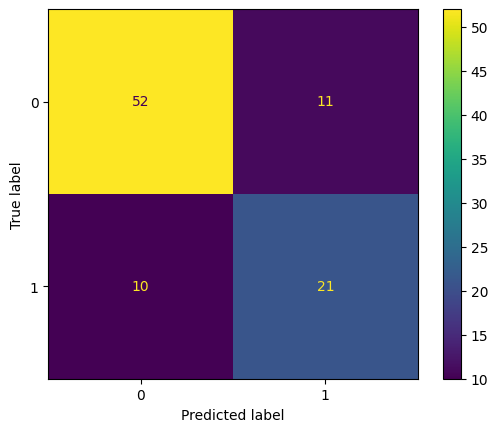

In [50]:
prevision_arbol = arbol.predict(x_val)
ConfusionMatrixDisplay.from_predictions(y_val, prevision_arbol);

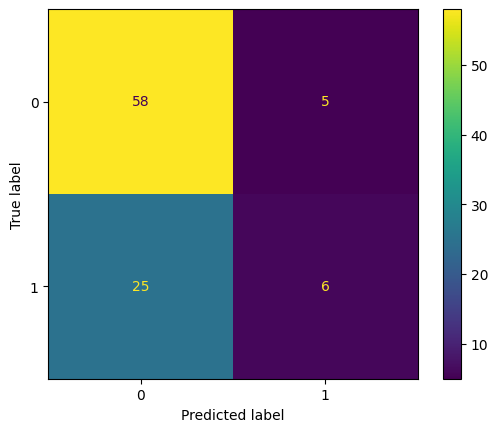

In [51]:
prevision_rf = random_forest.predict(x_val)
ConfusionMatrixDisplay.from_predictions(y_val, prevision_rf);

# Aula 2

### Desafío 1

Extraiga las métricas de precisión, recall, exactitud y F1-Score de los modelos de clasificación generados en el desafío de la lección 1.

Para extraer las métricas de un modelo, primero importaremos las funciones que calculan automáticamente:

- accuracy_score

- recall_score

- precision_score

- f1_score

In [52]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

Ahora vamos a calcular cada una de las métricas para los dos modelos, utilizando los datos reales y los valores previstos:

In [53]:
prevision_arbol = arbol.predict(x_val)

print(f'Exactitud (Decision Tree): {accuracy_score(y_val, prevision_arbol)}')
print(f'Recall (Decision Tree): {recall_score(y_val, prevision_arbol)}')
print(f'Precisión (Decision Tree): {precision_score(y_val, prevision_arbol)}')
print(f'F1_Score (Decision Tree): {f1_score(y_val, prevision_arbol)}')

Exactitud (Decision Tree): 0.776595744680851
Recall (Decision Tree): 0.6774193548387096
Precisión (Decision Tree): 0.65625
F1_Score (Decision Tree): 0.6666666666666666


In [54]:
prevision_rf = random_forest.predict(x_val)

print(f'Exactitud (Random Forest): {accuracy_score(y_val, prevision_rf)}')
print(f'Recall (Random Forest): {recall_score(y_val, prevision_rf)}')
print(f'Precisión (Random Forest): {precision_score(y_val, prevision_rf)}')
print(f'F1_Score (Random Forest): {f1_score(y_val, prevision_rf)}')

Exactitud (Random Forest): 0.6808510638297872
Recall (Random Forest): 0.1935483870967742
Precisión (Random Forest): 0.5454545454545454
F1_Score (Random Forest): 0.2857142857142857


### Desafío 2

Obtén la curva ROC y la métrica AUC de los modelos de clasificación generados en el desafío de la lección 1, comparando las curvas en el mismo gráfico.  

*Como consejo, revisa la documentación de `Scikit-learn` en este [enlace](https://scikit-learn.org/stable/auto_examples/release_highlights/plot_release_highlights_0_22_0.html#new-plotting-api) y busca una forma de presentar los resultados de las curvas en el mismo gráfico utilizando Matplotlib.*

Para obtener el gráfico de la curva ROC y la métrica AUC, primero importaremos las funciones para generar el gráfico y calcular la métrica:

In [55]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

Para presentar los resultados de la curva ROC en el mismo gráfico, podemos almacenar el gráfico en una variable y utilizar el parámetro ax para usar el gráfico ya existente como base:

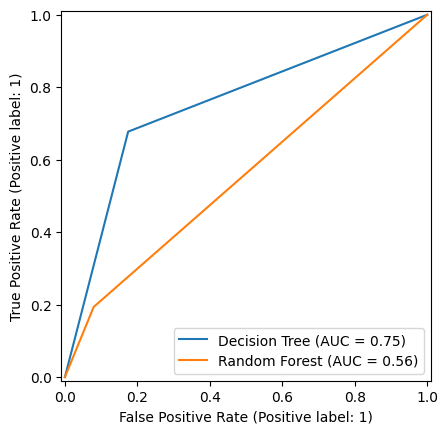

In [56]:
curva_roc = RocCurveDisplay.from_predictions(y_val, prevision_arbol, name = 'Decision Tree')
curva_roc = RocCurveDisplay.from_predictions(y_val, prevision_rf, name = 'Random Forest', ax = curva_roc.ax_)

Ahora solo falta usar el método roc_auc_score para calcular el AUC de los dos modelos:

In [57]:
print(f'AUC (Decision Tree): {roc_auc_score(y_val, prevision_arbol)}')
print(f'AUC (Random Forest): {roc_auc_score(y_val, prevision_rf)}')

AUC (Decision Tree): 0.7514080901177674
AUC (Random Forest): 0.5570916538658475


### Desafío 3

Obtén la curva de precisión vs. recall y la métrica AP de los modelos de clasificación generados en el desafío de la lección 1, comparando las curvas en el mismo gráfico.  

*Como sugerencia, revisa la documentación de `Scikit-learn` en este [enlace](https://scikit-learn.org/stable/auto_examples/release_highlights/plot_release_highlights_0_22_0.html#new-plotting-api) y busca una forma de presentar los resultados de las curvas en el mismo gráfico utilizando Matplotlib.*

Para obtener el gráfico de la curva de precisión x recall y la métrica AP, primero importaremos las funciones para generar el gráfico y calcular la métrica:

In [58]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

Para presentar los resultados de la curva de precisión x recall en el mismo gráfico, podemos almacenar el gráfico en una variable y utilizar el parámetro ax para usar el gráfico ya existente como base:

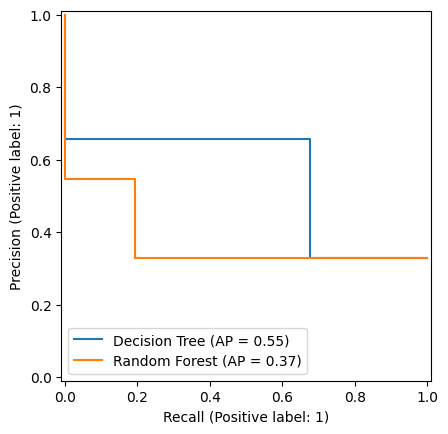

In [59]:
curva_precision_recall = PrecisionRecallDisplay.from_predictions(y_val, prevision_arbol, name = 'Decision Tree')
curva_precision_recall = PrecisionRecallDisplay.from_predictions(y_val, prevision_rf, name = 'Random Forest', ax = curva_precision_recall.ax_)

Ahora solo falta usar el método average_precision_score para calcular el AP de los dos modelos:

In [60]:
print(f'AP (Decision Tree): {average_precision_score(y_val, prevision_arbol)}')
print(f'AP (Random Forest): {average_precision_score(y_val, prevision_rf)}')

AP (Decision Tree): 0.5509394303363074
AP (Random Forest): 0.3715292943158419


### Desafío 4

Genera los informes de métricas de los modelos de clasificación generados en el desafío de la lección 1.

Para generar el informe de métricas, primero necesitamos importar la función classification_report:

In [61]:
from sklearn.metrics import classification_report

A partir de ahí, podemos generar los informes para cada uno de los modelos, utilizando los valores reales y previstos:

In [62]:
print('Decision Tree')
print(classification_report(y_val, prevision_arbol))
print('Random Forest')
print(classification_report(y_val, prevision_rf))

Decision Tree
              precision    recall  f1-score   support

           0       0.84      0.83      0.83        63
           1       0.66      0.68      0.67        31

    accuracy                           0.78        94
   macro avg       0.75      0.75      0.75        94
weighted avg       0.78      0.78      0.78        94

Random Forest
              precision    recall  f1-score   support

           0       0.70      0.92      0.79        63
           1       0.55      0.19      0.29        31

    accuracy                           0.68        94
   macro avg       0.62      0.56      0.54        94
weighted avg       0.65      0.68      0.63        94



# Aula 3

Para solucionar el desafío, podemos explorar la documentación y darnos cuenta de que podemos utilizar una lista de métricas en el parámetro **scoring**. De esta manera, vamos a utilizar el código de la clase para validar el modelo con **KFold**, pero usando todas las métricas de evaluación de una sola vez:

In [63]:
from sklearn.model_selection import KFold, cross_validate

modelo = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, x, y, cv=kf, scoring = ['accuracy','recall', 'precision', 'f1'])
cv_resultados

{'fit_time': array([0.00653172, 0.00409555, 0.00433612, 0.0038116 , 0.00420213]),
 'score_time': array([0.01284456, 0.00949526, 0.01069522, 0.01007795, 0.00979829]),
 'test_accuracy': array([0.68      , 0.65333333, 0.64      , 0.62666667, 0.7027027 ]),
 'test_recall': array([0.55      , 0.60869565, 0.33333333, 0.29166667, 0.51724138]),
 'test_precision': array([0.42307692, 0.4516129 , 0.5       , 0.38888889, 0.65217391]),
 'test_f1': array([0.47826087, 0.51851852, 0.4       , 0.33333333, 0.57692308])}

Para generar el intervalo de confianza para las métricas, podemos calcular la media y la desviación estándar de cada métrica y utilizar la función print() para presentar el resultado en pantalla. De este modo, podemos construir una función para crear este informe, usando un for para recorrer cada una de las claves del diccionario que acceden a las métricas:


In [64]:
def informe_metricas(resultados):
    for metrica in ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']:
        media = resultados[metrica].mean()
        desvio_estandar = resultados[metrica].std()
        print(f'Intervalo de confianza({metrica}): [{media-2*desvio_estandar}, {min(media+2*desvio_estandar, 1.0)}]')

Por último, solo hay que ejecutar la función, utilizando cv_resultados como parámetro:

In [65]:
informe_metricas(cv_resultados)

Intervalo de confianza(test_accuracy): [0.6055669799624509, 0.7155141011186305]
Intervalo de confianza(test_recall): [0.21059998284650036, 0.7097748297472029]
Intervalo de confianza(test_precision): [0.29910373639819854, 0.66719731489584]
Intervalo de confianza(test_f1): [0.28921325446386087, 0.6336010648721975]


### Desafío 1

Crea una función para calcular el intervalo de confianza de los resultados de una validación cruzada con 2 desviaciones estándar. La función debe tener un parámetro para recibir una lista con los desempeños de la validación cruzada y otro para presentar el nombre del modelo utilizado en la validación cruzada.  

Ejemplo de retorno de la función:  

> Intervalo de confianza ("nombre del modelo"): ["valor mínimo del intervalo", "valor máximo del intervalo"]


Para calcular el intervalo de confianza de los resultados de la validación cruzada, necesitamos la lista de resultados y también el nombre del modelo para presentarlo en la función print.

Vamos a crear una función llamada intervalo_conf que recibe dos parámetros: resultados y nombre_modelo.

A partir de los resultados, podemos extraer la media y la desviación estándar y generar el intervalo de confianza que está a una distancia de dos desviaciones estándar por debajo y por encima de esa media:

In [66]:
def intervalo_conf(resultados, nombre_modelo):
    media = resultados.mean()
    desvio_tipico = resultados.std()
    print(f'Intervalo de confianza ({nombre_modelo}): [{media - 2*desvio_tipico}, {min(media + 2*desvio_tipico, 1)}]')

### Desafío 2

Evalúe el desempeño de los modelos con un intervalo de confianza utilizando la validación cruzada con el método [`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html), usando 10 partes y barajando los datos antes de la separación. Utilice el método [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html), que no devuelve el tiempo de ejecución, solo las métricas.

El primer paso a realizar es importar la función cross_val_score y el método KFold:

In [67]:
from sklearn.model_selection import cross_val_score, KFold

Hecho esto, vamos a inicializar los modelos y utilizar el KFold con n_splits=10 para generar una división de 10 partes. Además, utilizaremos el parámetro shuffle=True para barajar los datos antes de realizar la separación.

Posteriormente, vamos a usar el método cross_val_score para realizar el procedimiento de validación cruzada con los dos modelos y generar el intervalo de confianza a partir de los resultados:

In [68]:
arbol = DecisionTreeClassifier(max_depth = 3)
random_forest = RandomForestClassifier(max_depth = 2)

kf = KFold(n_splits = 10, shuffle = True, random_state = 5)

resultado_arbol = cross_val_score(arbol, x, y, cv = kf)
resultado_rf = cross_val_score(random_forest, x, y, cv = kf)

intervalo_conf(resultado_arbol, 'Decision Tree')
intervalo_conf(resultado_rf, 'Random Forest')

Intervalo de confianza (Decision Tree): [0.5337181765177326, 0.8684155361422958]
Intervalo de confianza (Random Forest): [0.6126019369949032, 0.7558191156366758]


### Desafío 3

Evalúe el desempeño de los modelos con un intervalo de confianza utilizando la validación cruzada (`cross_val_score`) con el método [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html#sklearn.model_selection.StratifiedKFold), usando 10 partes y barajando los datos antes de la separación, y evaluando la métrica F1-Score.

El primer paso a realizar es importar la función cross_val_score y el método StratifiedKFold:

In [69]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

El paso sigue de forma muy parecida al desafío anterior, diferenciándose en la elección del método de validación que será estratificado, con el método StratifiedKFold. Además, la métrica de evaluación necesita ser alterada a f1, a partir del parámetro scoring de la función cross_val_score:

In [70]:
arbol = DecisionTreeClassifier(max_depth = 3)
random_forest = RandomForestClassifier(max_depth = 2)

skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)

resultado_arbol = cross_val_score(arbol, x, y, cv = skf, scoring = 'f1')
resultado_rf = cross_val_score(random_forest, x, y, cv = skf, scoring =  'f1')

intervalo_conf(resultado_arbol, 'Decision Tree')
intervalo_conf(resultado_rf, 'Random Forest')

Intervalo de confianza (Decision Tree): [0.2681981750463088, 0.7354166140441551]
Intervalo de confianza (Random Forest): [-0.027260127753314267, 0.5824286417298776]


### Desafío 4

Evalúe el desempeño de los modelos utilizando la validación cruzada (`cross_val_score`) con el método [`LeaveOneOut`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html).  

El método *LeaveOneOut* generará un modelo para cada una de las filas de la base de datos, por lo que la lista de resultados tendrá una tasa de acierto de solo 0 o 1 para cada modelo. Por lo tanto, extraiga únicamente el promedio del resultado, sin utilizar el intervalo de confianza.


El primer paso a realizar es importar la función cross_val_score y el método LeaveOneOut:

In [71]:
from sklearn.model_selection import cross_val_score, LeaveOneOut

La construcción del código se da de forma muy parecida a los desafíos anteriores.

Primero, los modelos son inicializados y luego se inicializa el método LeaveOneOut, sin la necesidad de definir parámetros, ya que recorre toda la base de datos hasta que todos los valores han sido elegidos como datos de validación y el resto como datos de entrenamiento.

Aquí vamos a calcular solo la media de los resultados, por lo tanto, utilizaremos el método mean() en cada una de las listas de resultados para obtener la precisión media.

In [72]:
arbol = DecisionTreeClassifier(max_depth = 3)
random_forest = RandomForestClassifier(max_depth = 2)

loo = LeaveOneOut()

resultado_arbol = cross_val_score(arbol, x, y, cv = loo)
resultado_rf = cross_val_score(random_forest, x, y, cv = loo)

print(f'Exactitud promedio (Decision Tree): {resultado_arbol.mean()}')
print(f'Exactitud promedio (Random Forest):{resultado_rf.mean()}')

Exactitud promedio (Decision Tree): 0.7085561497326203
Exactitud promedio (Random Forest):0.6925133689839572


# Aula 4

### Desafío 1

Verifique la proporción de datos de la variable objetivo en el conjunto de datos de diabetes. Este análisis puede realizarse a partir del porcentaje de datos o mediante el uso de un gráfico de conteo para comprender si existe un desequilibrio en los datos.

Para chequear la proporción de los datos en la variable objetivo, podemos usar el método value_counts que realiza el conteo de los datos de cada categoría de la columna. También podemos usar el parámetro normalize = True para devolver el resultado en porcentaje:

In [73]:
datos['diabetes'].value_counts(normalize = True)

,proportion
diabetes,
0,0.670051
1,0.329949


Otra forma de analizar es a través de un gráfico. Podemos usar el countplot() de la biblioteca seaborn:

In [74]:
import seaborn as sns

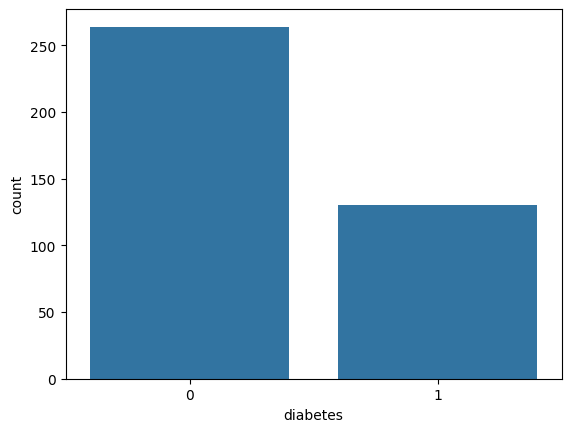

In [75]:
sns.countplot(datos, x = 'diabetes');

### Desafío 2

Utilice un [`pipeline`](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html) que incluya el ajuste del modelo y el balanceo de los datos mediante oversampling con [`SMOTE`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html), obteniendo el promedio del F1-Score a partir de una validación cruzada con `StratifiedKFold`.

El primer paso es importar el método Pipeline y el SMOTE para balancear los datos:

In [76]:
from imblearn.pipeline import Pipeline as imbpipeline

In [77]:
from imblearn.over_sampling import SMOTE

Hecho esto, podemos inicializar el modelo, crear el pipeline con las tareas de oversampling y del modelo, y realizar la validación cruzada con el StratifiedKfold, obteniendo la media de la métrica F1-Score:

In [78]:
arbol = DecisionTreeClassifier(max_depth = 3)
pipeline = imbpipeline([('oversample', SMOTE()), ('arbol', arbol)])
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)
resultado_arbol = cross_val_score(pipeline, x, y, cv = skf, scoring = 'f1')
print(f'F1 (Decision Tree):{resultado_arbol.mean()}')

F1 (Decision Tree):0.5772272146754905


In [79]:
random_forest = RandomForestClassifier(max_depth = 2)
pipeline = imbpipeline([('oversample', SMOTE()), ('random_forest', random_forest)])
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)
resultado_rf = cross_val_score(pipeline, x, y, cv = skf, scoring = 'f1')
print(f'F1 (Random Forest):{resultado_rf.mean()}')

F1 (Random Forest):0.6333915481996685


### Desafío 3

Utilice un [`pipeline`](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html) que incluya el ajuste del modelo y el balanceo de los datos mediante undersampling con [`NearMiss`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) en su versión 3, obteniendo el promedio del F1-Score a partir de una validación cruzada con `StratifiedKFold`.

El primer paso es importar el método Pipeline y el NearMiss para balancear los datos:

In [80]:
from imblearn.pipeline import Pipeline as imbpipeline

In [81]:
from imblearn.under_sampling import NearMiss

Hecho esto, podemos inicializar el modelo, crear el pipeline con las tareas de undersampling y del modelo, y realizar la validación cruzada con el StratifiedKfold, obteniendo la media de la métrica F1-Score:

In [82]:
arbol = DecisionTreeClassifier(max_depth = 3)
pipeline = imbpipeline([('undersample', NearMiss(version = 3)), ('arbol', arbol)])
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)
resultado_arbol = cross_val_score(pipeline, x, y, cv = skf, scoring = 'f1')
print(f'F1 (Decision Tree):{resultado_arbol.mean()}')

F1 (Decision Tree):0.5460263484053807


In [83]:
random_forest = RandomForestClassifier(max_depth = 2)
pipeline = imbpipeline([('undersample', NearMiss(version = 3)), ('random_forest', random_forest)])
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)
resultado_rf = cross_val_score(pipeline, x, y, cv = skf, scoring = 'f1')
print(f'F1 (Random Forest):{resultado_rf.mean()}')

F1 (Random Forest):0.5950973860693356


### Desafío 4

Elige el modelo que obtuvo el mejor desempeño al comparar las estrategias de oversampling y undersampling y realiza la prueba del modelo con los datos de prueba que fueron separados al inicio de los desafíos.

El modelo que obtuvo mayor rendimiento en las pruebas del desafío fue el RandomForest, usando el max_depth = 2 en la estrategia de undersampling. Por lo tanto, vamos a balancear los datos y utilizar este modelo en todos los datos balanceados.

Por último, vamos a validar el modelo en datos de prueba, no vistos hasta ahora:

              precision    recall  f1-score   support

           0       0.80      0.62      0.70        13
           1       0.50      0.71      0.59         7

    accuracy                           0.65        20
   macro avg       0.65      0.66      0.64        20
weighted avg       0.70      0.65      0.66        20



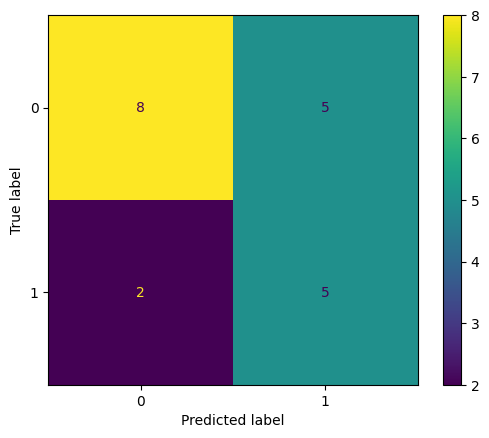

In [84]:
undersample = NearMiss(version = 3)
x_balanceado, y_balanceado = undersample.fit_resample(x, y)

modelo = RandomForestClassifier(max_depth = 2)
modelo.fit(x_balanceado, y_balanceado)
y_previsto = modelo.predict(x_test)

print(classification_report(y_test, y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto);